In [1]:
# Repository path setup. This lets the notebook run from either the repo root or the notebooks/ folder.
from pathlib import Path
import os

_REPO_ROOT = Path.cwd()
if not (_REPO_ROOT / "data").exists() and (_REPO_ROOT.parent / "data").exists():
    _REPO_ROOT = _REPO_ROOT.parent
os.chdir(_REPO_ROOT)
# print(f"Working directory: {_REPO_ROOT}")

# CTN-0094 Benchmark Analysis Notebook

This notebook reproduces the analysis-generated figures and tables used in the NeurIPS submission.
It is organized into the following sections:

1. Data and sequence construction utilities  
2. Models and training utilities  
3. Benchmark split and complexity utilities  
4. Training and benchmark setup  
5. Original test-set results  
6. Cohort-resampling results and figure generation

Run the notebook from top to bottom to regenerate the reported outputs.

## 1. Data and sequence construction utilities

In [2]:
import warnings
warnings.filterwarnings("ignore")
def generate_dataset_from_dataframe(
    df, miss_value, random_seed=42, future_window=4, n_timesteps=24,
    daily_treatment=True, restrict_length=-1, select_class=None, prev_week_mode=1,
    include_treat_stats=True,
    include_tlstm_treat=True
):
    import numpy as np
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset

    np.random.seed(random_seed)

    static_features = df[['treatment_group','age', 'race', 'is_male', 'heroin_inject', 'TLFB_Heroin',
                          'TLFB_THC', 'TLFB_Alcohol', 'TLFB_Cocaine', 'TLFB_Methadone',
                          'TLFB_Amphetamine', 'UDS_Benzodiazepine', 'UDS_Opioid',
                          'UDS_Thc', 'UDS_Buprenorphine', 'UDS_Methadone', 'UDS_Cocaine',
                          'UDS_Alcohol', 'UDS_Amphetamine', 'UDS_Sedatives', 'UDS_Mdma/Hallucinogen']].values

    treat_features = df['treat_wks'].tolist()

    # ----- ORIGINAL weekly time-series features -----
    time_series_raw = df.filter(regex='week').values
    time_series_raw[time_series_raw == -1] = miss_value

    N = time_series_raw.shape[0]
    n_orig_features = time_series_raw.shape[1] // n_timesteps
    orig_weekly = (
        time_series_raw
        .reshape(N, n_orig_features, n_timesteps)
        .transpose(0, 2, 1)
    )

    if include_treat_stats:
        week_len = 7

        def parse_daily_seq(colname):
            seq_list = df[colname].tolist()
            daily_arr = []
            for s in seq_list:
                if not isinstance(s, str) or s.strip() == "":
                    arr = np.zeros(n_timesteps * week_len, dtype=float)
                else:
                    vals = s.split(',')
                    if len(vals) < n_timesteps * week_len:
                        vals = vals + ['0'] * (n_timesteps * week_len - len(vals))
                    elif len(vals) > n_timesteps * week_len:
                        vals = vals[:n_timesteps * week_len]
                    arr = np.array([float(x) for x in vals], dtype=float)
                daily_arr.append(arr)
            daily_arr = np.stack(daily_arr, axis=0)  # (N, 168)
            return daily_arr.reshape(N, n_timesteps, week_len)  # (N, 24, 7)

        def weekly_stats(daily_3d):
            wk_min  = daily_3d.min(axis=2, keepdims=True)
            wk_max  = daily_3d.max(axis=2, keepdims=True)
            wk_mean = daily_3d.mean(axis=2, keepdims=True)
            return np.concatenate([wk_min, wk_max, wk_mean], axis=2)  # (N, 24, 3)

        bup_stats = weekly_stats(parse_daily_seq('treat_Buprenorphine_amt'))
        met_stats = weekly_stats(parse_daily_seq('treat_Methadone_amt'))
        ntx_stats = weekly_stats(parse_daily_seq('treat_Naltrexone_amt'))

        treat_weekly_stats = np.concatenate([bup_stats, met_stats, ntx_stats], axis=2)  # (N, 24, 9)
        time_series_features = np.concatenate([orig_weekly, treat_weekly_stats], axis=2)
    else:
        time_series_features = orig_weekly

    # --- variable-length sample creation ---
    def create_variable_length_sequences_with_labels(static_features, time_series_features, treat_features):
        X_static_list, X_time_series_list, y_list = [], [], []
        sample_index, week_index, T_time_series_list = [], [], []
        week_len = 7
        start_week = 3

        for i in range(len(static_features)):
            treat_rec = np.array([float(ele) for ele in treat_features[i].split(',')])

            for t in range(start_week, n_timesteps - future_window):
                if (select_class is not None) and (time_series_features[i, t, 0] != select_class):
                    continue
                if restrict_length != -1 and (t + 1 != restrict_length):
                    continue

                if include_tlstm_treat:
                    treat_ts = treat_rec.reshape(n_timesteps, week_len)
                    if prev_week_mode == 1:
                        T_time_series_list.append(treat_ts[:t+1, :])
                    elif prev_week_mode == 2:
                        T_time_series_list.append(treat_ts[t-3:t+1, :])
                    elif prev_week_mode == 3:
                        temp_vec = treat_ts[:t+1, :].copy()
                        temp_vec[:-3] = -3
                        T_time_series_list.append(temp_vec)

                X_static_list.append(static_features[i])

                if prev_week_mode == 1:
                    X_time_series_list.append(time_series_features[i, :t+1, :])
                    week_index.append(t)
                elif prev_week_mode == 2:
                    X_time_series_list.append(time_series_features[i, t-3:t+1, :])
                    week_index.append(3)
                elif prev_week_mode == 3:
                    temp_vec = time_series_features[i, :t+1, :].copy()
                    temp_vec[:-3] = -3
                    X_time_series_list.append(temp_vec)
                    week_index.append(t)

                sample_index.append(i)

                labels = time_series_features[i, t+1, 0]
                labels = 1 if labels != 0 else 0
                y_list.append(labels)

        return X_static_list, X_time_series_list, y_list, sample_index, week_index, T_time_series_list

    X_static, X_time_series, y, sample_index, week_index, T_time_series = create_variable_length_sequences_with_labels(
        static_features, time_series_features, treat_features
    )

    # tensors + padding
    X_static = torch.tensor(X_static, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)  # better: long for CrossEntropy
    X_time_series = [torch.tensor(seq, dtype=torch.float32) for seq in X_time_series]
    X_time_series = nn.utils.rnn.pad_sequence(X_time_series, batch_first=True)
    sample_index = torch.tensor(sample_index, dtype=torch.int64)
    week_index = torch.tensor(week_index, dtype=torch.int64)

    if include_tlstm_treat:
        T_time_series = [torch.tensor(seq, dtype=torch.float32) for seq in T_time_series]
        T_time_series = nn.utils.rnn.pad_sequence(T_time_series, batch_first=True)
        dataset = TensorDataset(X_time_series, X_static, y, sample_index, week_index, T_time_series)
    else:
        dataset = TensorDataset(X_time_series, X_static, y, sample_index, week_index)

    return dataset

## 2. Model and training utilities

In [3]:
########### Define LSTM model, assuming Static Features Impact Predictions Over Time (time-dependent)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

class TimeDependentLSTM(nn.Module):
    def __init__(self, input_size1, hidden_size, num_static_features, input_size2=7):
        super(TimeDependentLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size1, hidden_size, batch_first=True)
        self.fc_time_series = nn.Linear(hidden_size, 32)
        self.tlstm = nn.LSTM(input_size2, hidden_size, batch_first=True)
        self.fc_t_time_series = nn.Linear(hidden_size, 32)
        self.fc_static = nn.Linear(num_static_features, 32)
        self.fc_combined_all = nn.Linear(96, 16)
        self.fc_combined = nn.Linear(64, 16)
        self.fc_single = nn.Linear(32, 16)
        self.output = nn.Linear(16, 2)

    def forward(self, x_time_series, x_static, t_time_series):
        lstm_out, _ = self.lstm(x_time_series)
        x_time_series = torch.relu(self.fc_time_series(lstm_out))

        if (not x_static is None) and (not t_time_series is None):
            # Expand static features across the time axis
            x_static_expanded = x_static.unsqueeze(1).expand(-1, x_time_series.size(1), -1)
            x_static = torch.relu(self.fc_static(x_static_expanded))

            tlstm_out, _ = self.tlstm(t_time_series)
            t_time_series = torch.relu(self.fc_t_time_series(tlstm_out))

            # Combine time-series and static features
            combined = torch.cat((x_time_series, t_time_series, x_static), dim=2)
            combined = torch.relu(self.fc_combined_all(combined))

            output = self.output(combined).squeeze(-1)
        elif not x_static is None:
            # Expand static features across the time axis
            x_static_expanded = x_static.unsqueeze(1).expand(-1, x_time_series.size(1), -1)
            x_static = torch.relu(self.fc_static(x_static_expanded))
            # Combine time-series and static features
            combined = torch.cat((x_time_series, x_static), dim=2)
            combined = torch.relu(self.fc_combined(combined))
            output = self.output(combined).squeeze(-1)
        elif not t_time_series is None:
            tlstm_out, _ = self.tlstm(t_time_series)
            t_time_series = torch.relu(self.fc_t_time_series(tlstm_out))
            combined = torch.cat((x_time_series, t_time_series), dim=2)
            combined = torch.relu(self.fc_combined(combined))
            output = self.output(combined).squeeze(-1)
        else:
            single = torch.relu(self.fc_single(x_time_series))
            output = self.output(single).squeeze(-1)

        return output

In [4]:
from sklearn.utils.class_weight import compute_class_weight
def load_LSTM_model_pars(train_dataset, hidden_size=64, lr=0.0005, device="cpu"):
    model = TimeDependentLSTM(
        train_dataset[0][0].shape[1],
        hidden_size,
        train_dataset[0][1].shape[0]
    ).to(device)

    classes = np.unique(train_dataset[:][2].numpy())
    class_weights = compute_class_weight(
        'balanced',
        classes=classes,
        y=train_dataset[:][2].numpy()
    )
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    return model, criterion, optimizer

In [5]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import matplotlib.pyplot as plt

def fit_model(model, train_loader, val_loader, criterion, optimizer, no_static=False, include_tlstm_treat=False, n_epochs=15, device="cpu", return_history=False):
    model.to(device)
    best_val = -1
    best_state = None
    best_epoch = -1

    history = {"epoch": [], "train_loss": [], "val_loss": []}
    for epoch in range(n_epochs):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        val_loss_sum = 0.0
        val_n = 0
        for batch in train_loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                t_ts = t_ts.to(device)
            else:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.to(device)
            week_index = week_index.to(device)

            optimizer.zero_grad()
            logits_all = model(x_ts, None if no_static else x_static, t_ts)
            logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
            loss = criterion(logits, y)
            train_loss_sum += loss.item() * y.size(0)
            train_n += y.size(0)
            loss.backward()
            optimizer.step()

        # quick val AUROC
        model.eval()
        with torch.no_grad():
            for batch in val_loader:
                if include_tlstm_treat:
                    x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                    t_ts = t_ts.to(device)
                else:
                    x_ts, x_static, y, sample_idx, week_index = batch
                    t_ts = None

                x_ts = x_ts.to(device)
                x_static = x_static.to(device)
                y = y.to(device)
                week_index = week_index.to(device)

                logits_all = model(x_ts, None if no_static else x_static, t_ts)
                logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
                val_loss = criterion(logits, y)

                val_loss_sum += val_loss.item() * y.size(0)
                val_n += y.size(0)

        val_metrics = evaluate_week_level(model, val_loader, no_static=no_static, include_tlstm_treat=include_tlstm_treat, device=device)
        if val_metrics["auroc"] > best_val:
            best_val = val_metrics["auroc"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch

        print(f"[epoch {epoch+1}] val AUROC={val_metrics['auroc']:.3f} val F1={val_metrics['f1']:.3f}")
        history["epoch"].append(epoch + 1)
        history["train_loss"].append(train_loss_sum / max(train_n, 1))
        history["val_loss"].append(val_loss_sum / max(val_n, 1))

    if best_state is not None:
        model.load_state_dict(best_state)

    if return_history:
        return model, history, best_epoch
    return model, best_epoch


def evaluate_week_level(model, loader, no_static=False, include_tlstm_treat=False, device="cpu"):
    model.eval()
    ys = []
    ps = []

    with torch.no_grad():
        for batch in loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                t_ts = t_ts.to(device)
            else:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.to(device)
            week_index = week_index.to(device)

            logits_all = model(x_ts, None if no_static else x_static, t_ts)
            logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
            prob = F.softmax(logits, dim=1)[:, 1]  # P(relapse)

            ys.append(y.detach().cpu().numpy())
            ps.append(prob.detach().cpu().numpy())

    y_all = np.concatenate(ys)
    p_all = np.concatenate(ps)

    auroc = roc_auc_score(y_all, p_all)
    auprc = average_precision_score(y_all, p_all)

    pred = (p_all >= 0.5).astype(int)
    f1 = f1_score(y_all, pred)

    return {"auroc": auroc, "auprc": auprc, "f1": f1}


def evaluate_by_pe_tier(model, df_test, test_dataset, no_static=False, include_tlstm_treat=False, device="cpu"):
    """
    df_test rows correspond to patients; test_dataset contains many (patient, week) samples.
    We'll use sample_index to map week-level samples back to patient PE tier.
    """
    loader = DataLoader(test_dataset, batch_size=512, shuffle=False)
    model.eval()

    tiers = df_test["Target_Permutation_Entropy"].values
    tier_y = {}
    tier_p = {}

    with torch.no_grad():
        for batch in loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch
                t_ts = t_ts.to(device)
            else:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            week_index = week_index.to(device)

            logits_all = model(x_ts, None if no_static else x_static, t_ts)
            logits = logits_all[torch.arange(logits_all.size(0), device=device), week_index, :]
            p = F.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            y_np = y.detach().cpu().numpy()
            sidx = sample_idx.detach().cpu().numpy()

            for yi, pi, si in zip(y_np, p, sidx):
                tier = int(tiers[int(si)])
                tier_y.setdefault(tier, []).append(int(yi))
                tier_p.setdefault(tier, []).append(float(pi))

    out = {}
    for tier in sorted(tier_y.keys()):
        yv = np.array(tier_y[tier])
        pv = np.array(tier_p[tier])
        if len(np.unique(yv)) < 2:
            out[tier] = {"n": len(yv), "auroc": np.nan, "auprc": np.nan}
        else:
            out[tier] = {
                "n": len(yv),
                "auroc": roc_auc_score(yv, pv),
                "auprc": average_precision_score(yv, pv),
            }
    return out


def plot_pe_tier_metrics(metrics_a, metrics_b, label_a, label_b, outpath):
    tiers = sorted(set(metrics_a.keys()) | set(metrics_b.keys()))
    auroc_a = [metrics_a.get(t, {}).get("auroc", np.nan) for t in tiers]
    auroc_b = [metrics_b.get(t, {}).get("auroc", np.nan) for t in tiers]

    x = np.arange(len(tiers))
    plt.figure(figsize=(8, 4))
    plt.plot(x, auroc_a, marker="o", label=label_a)
    plt.plot(x, auroc_b, marker="o", label=label_b)
    plt.xticks(x, tiers)
    plt.xlabel("Permutation Entropy Tier")
    plt.ylabel("AUROC (week-level)")
    plt.ylim(0.5, 1.0)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

## 3. Benchmark split and complexity utilities

In [6]:
import math
import numpy as np
from collections import Counter

def calculate_permutation_entropy(time_series, D=3):
    """
    Calculate normalized permutation entropy for a categorical time series.
    """
    n = len(time_series)
    if n < D:
        raise ValueError("Time-series length must be greater than embedding dimension.")

    ordinal_patterns = []
    for i in range(n - D + 1):
        segment = time_series[i:i + D]
        ordinal_pattern = tuple(np.argsort(segment))
        ordinal_patterns.append(ordinal_pattern)

    pattern_counts = Counter(ordinal_patterns)
    total_patterns = len(ordinal_patterns)
    probabilities = np.array(list(pattern_counts.values())) / total_patterns

    permutation_entropy = -np.sum(probabilities * np.log(probabilities))
    max_entropy = np.log(math.factorial(D))
    return permutation_entropy / max_entropy

def hamming_distance(ts1, ts2):
    assert len(ts1) == len(ts2), "Time-series must have the same length"
    return np.sum(ts1 != ts2) / len(ts1)

In [7]:
def split_train_test_stratify_permutation_entropy(csv_file='data/processed/static_timeSeries_new.csv', test_ratio = 0.2, val_ratio=None, bins=5, no_filter=False):
######################## Function to generate traing, validation, test data sets
    random_seed = 42
    n_timesteps = 24  # number of time points

    df = pd.read_csv(csv_file)

    start_idx = df.columns.tolist().index('Opioid_week0')
    if df.columns[start_idx+n_timesteps-1] != 'Opioid_week23':
        print("The columns of original data is not correct! Please check the static_timeSeries_new.csv file!")
        return
    print(f"Raw data: {df.shape[0]}")
    miss_origin = list(set(np.unique(df.iloc[:,start_idx:(start_idx+n_timesteps)].values))-set([0,1]))[0]
    df_miss = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)==n_timesteps*miss_origin]
    df_positive = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)==n_timesteps] # remove all positive
    df_negative = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)==0] # remove all negative

    df = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)!=n_timesteps*miss_origin]
    print(f"Filter all missing: {df.shape[0]}")
    df = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)!=n_timesteps] # remove all positive
    print(f"Filter all positive: {df.shape[0]}")
    df = df[df.iloc[:,start_idx:(start_idx+n_timesteps)].sum(axis=1)!=0] # remove all negative
    print(f"Filter all negative: {df.shape[0]}")

    perm_ent = []
    for i in range(df.shape[0]):
        perm_ent.append(calculate_permutation_entropy(df.iloc[i,start_idx:(start_idx+n_timesteps)]))

    perm_ent = np.array(perm_ent)
    perm_ent_lv = np.zeros_like(perm_ent)

    res = plt.hist(perm_ent,bins=5)
    plt.close()# Do not show the plot

    bins_res = res[1]
    for bin in bins_res[:-1]:
        perm_ent_lv[perm_ent>=bin] += 1

    df['Target_Permutation_Entropy'] = perm_ent_lv
    print(np.unique(perm_ent_lv))

    if val_ratio is not None:
        val_size = int(df.shape[0]*val_ratio)
    else:
        val_size = int(df.shape[0]*test_ratio)

    test_size = int(df.shape[0]*test_ratio)

    df_rem, df_test = train_test_split(
        df,
        test_size=test_size,  # specifying the exact size for the test set
        stratify=df['Target_Permutation_Entropy'].astype(str),
        random_state=random_seed  # for reproducibility
    )
    df_rem = df_rem.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    if no_filter:
        df_rem = pd.concat([df_rem, df_positive, df_negative], ignore_index=True)

    df_train, df_val = train_test_split(
        df_rem,
        test_size=val_size,  # specifying the exact size for the test set
        stratify=df_rem['Target_Permutation_Entropy'].astype(str),
        random_state=random_seed  # for reproducibility
    )
    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)

    return df_rem, df_val, df_test, df_train, bins_res # Right now, the training set returned contains validation set as well.

In [8]:
# CIS + CIS-weighted metrics utilities
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

def compute_patient_complexity_from_weekly(df, opioid_prefix="Opioid_week", n_timesteps=24, miss_value=2, D=3):
    """Compute per-patient permutation entropy (PE) from the opioid weekly trajectory.
    Uses calculate_permutation_entropy(...) defined above.
    """
    cols = [f"{opioid_prefix}{i}" for i in range(n_timesteps)]
    if cols[0] not in df.columns:
        cols = [c for c in df.columns if c.startswith(opioid_prefix)][:n_timesteps]
    x = df[cols].values
    pe = np.zeros(df.shape[0], dtype=float)
    for i in range(df.shape[0]):
        pe[i] = calculate_permutation_entropy(x[i, :], D=D)
    return pe

def compute_cis_weights(df_any, gamma=1.5, D=3):
    """Compute CIS weights using cohort heterogeneity from training reference set.
    CIS_j = PE_j ** gamma.
    """
    pe_any = compute_patient_complexity_from_weekly(df_any, D=D)
    pe_any = np.clip(pe_any,0.0, 1.0)
    cis_any = pe_any ** gamma
    return cis_any

def weighted_brier(y_true, y_prob, w=None):
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob).astype(float)
    if w is None:
        return float(np.mean((y_prob - y_true) ** 2))
    w = np.asarray(w).astype(float)
    w = w / (w.sum() + 1e-12)
    return float(np.sum(w * (y_prob - y_true) ** 2))

def compute_metrics_binary(y_true, y_prob, sample_weight=None):
    """Return AUROC, AUPRC, and Brier score for binary classification."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    auroc = roc_auc_score(y_true, y_prob, sample_weight=sample_weight)
    auprc = average_precision_score(y_true, y_prob, sample_weight=sample_weight)
    brier = weighted_brier(y_true, y_prob, w=sample_weight)
    return {"auroc": float(auroc), "auprc": float(auprc), "brier": float(brier)}

def cis_weighted_aggregate_by_tier(tier_metrics, tier_weights):
    """Weighted aggregate across tiers using tier_weights (e.g., sum CIS in tier)."""
    metrics = set()
    for v in tier_metrics.values():
        metrics |= set(v.keys())
    total_w = sum(float(tier_weights.get(t, 0.0)) for t in tier_metrics.keys()) + 1e-12
    out = {}
    for m in metrics:
        num = 0.0
        for t in tier_metrics.keys():
            w = float(tier_weights.get(t, 0.0))
            if m in tier_metrics[t]:
                num += w * float(tier_metrics[t][m])
        out[m] = num / total_w
    return out

In [9]:
# CIS-weighted evaluation
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

def collect_week_level_predictions(model, dataset, include_tlstm_treat=False, device="cpu"):
    """Collect y_true, y_prob, and sample_index from a TensorDataset."""
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    model.eval()
    model.to(device)
    ys, ps, sidxs = [], [], []
    with torch.no_grad():
        for batch in loader:
            if include_tlstm_treat:
                x_ts, x_static, y, sample_idx, week_idx, t_ts = batch
            else:
                x_ts, x_static, y, sample_idx, week_idx = batch
                t_ts = None
            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.long().to(device)
            sample_idx = sample_idx.to(device)
            week_idx = week_idx.to(device)
            if t_ts is not None:
                t_ts = t_ts.to(device)
            out = model(x_ts, x_static, t_ts)
            b = torch.arange(out.size(0), device=device)
            out = out[b, week_idx, :]
            prob = F.softmax(out, dim=1)[:, 1]
            ys.append(y.detach().cpu().numpy())
            ps.append(prob.detach().cpu().numpy())
            sidxs.append(sample_idx.detach().cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps), np.concatenate(sidxs)

def cis_weighted_metrics_for_dataset(model, df_train_ref, df_eval, dataset_eval, include_tlstm_treat=False, device="cpu"):
    y_true, y_prob, sample_idx = collect_week_level_predictions(model, dataset_eval, include_tlstm_treat=include_tlstm_treat, device=device)
    pe_train = compute_patient_complexity_from_weekly(df_train_ref)
    pe_eval = compute_patient_complexity_from_weekly(df_eval)
    cis_eval = compute_cis_weights(df_eval)
    w = cis_eval[sample_idx.astype(int)]
    return compute_metrics_binary(y_true, y_prob, sample_weight=w)

## 4. Training and benchmark setup

device: cuda
Raw data: 2199
Filter all missing: 2030
Filter all positive: 2027
Filter all negative: 1929
[1. 2. 3. 4. 5.]


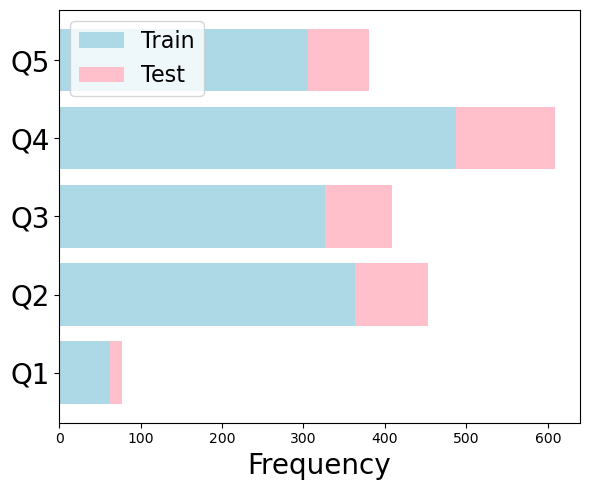

[epoch 1] val AUROC=0.838 val F1=0.786
[epoch 2] val AUROC=0.859 val F1=0.768
[epoch 3] val AUROC=0.869 val F1=0.834
[epoch 4] val AUROC=0.876 val F1=0.811
[epoch 5] val AUROC=0.875 val F1=0.831
[epoch 6] val AUROC=0.878 val F1=0.805
[epoch 7] val AUROC=0.880 val F1=0.811
[epoch 8] val AUROC=0.879 val F1=0.838
[epoch 9] val AUROC=0.882 val F1=0.839
[epoch 10] val AUROC=0.882 val F1=0.821
[epoch 11] val AUROC=0.879 val F1=0.837
[epoch 12] val AUROC=0.883 val F1=0.834
[epoch 13] val AUROC=0.879 val F1=0.835
[epoch 14] val AUROC=0.882 val F1=0.824
[epoch 15] val AUROC=0.884 val F1=0.833
[epoch 16] val AUROC=0.883 val F1=0.834
[epoch 17] val AUROC=0.882 val F1=0.826
[epoch 18] val AUROC=0.883 val F1=0.835
[epoch 19] val AUROC=0.883 val F1=0.826
[epoch 20] val AUROC=0.881 val F1=0.845
[epoch 21] val AUROC=0.881 val F1=0.840
[epoch 22] val AUROC=0.883 val F1=0.837
[epoch 23] val AUROC=0.883 val F1=0.833
[epoch 24] val AUROC=0.881 val F1=0.815
[epoch 25] val AUROC=0.883 val F1=0.824
[epoch 26

In [11]:
# Reproducible setup and benchmark split
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

os.makedirs("Figs", exist_ok=True)

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(SEED)
g = torch.Generator()
g.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Stratified development / test split by permutation-entropy tier
df_train, df_val, df_test, df_train_real, bins_res = split_train_test_stratify_permutation_entropy(
    csv_file="data/processed/static_timeSeries_new.csv", bins=5, no_filter=False
)

# Figure S2: tier composition in development and test splits
bins = 5
freqs = []
freqs_test = []
for i in range(1, bins + 1):
    freqs.append(np.sum(df_train["Target_Permutation_Entropy"] == i))
    freqs_test.append(np.sum(df_test["Target_Permutation_Entropy"] == i))

x = np.arange(1, bins + 1)
plt.figure(figsize=(6, 5))
plt.barh(x, freqs, label="Train", color="lightblue")
plt.barh(x, freqs_test, left=freqs, label="Test", color="pink")
plt.yticks(x, ["Q1", "Q2", "Q3", "Q4", "Q5"], fontsize=20)
plt.xlabel("Frequency", fontsize=20)
plt.legend(fontsize=16, loc="upper left")
plt.tight_layout()
plt.savefig("Figs/FigS2.pdf", bbox_inches="tight")
plt.show()


# Treatment-aware LSTM
treat_ds_train = generate_dataset_from_dataframe(
    df_train, miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)
treat_ds_train_real = generate_dataset_from_dataframe(
    df_train_real, miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)
treat_ds_val = generate_dataset_from_dataframe(
    df_val, miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)

treat_train_loader = DataLoader(treat_ds_train, batch_size=128, shuffle=True, generator=g)
treat_train_real_loader = DataLoader(treat_ds_train_real, batch_size=128, shuffle=True, generator=g)
treat_val_loader = DataLoader(treat_ds_val, batch_size=256, shuffle=False)

model_treat, crit_t, opt_t = load_LSTM_model_pars(treat_ds_train, hidden_size=64, lr=0.0005, device=device)
model_treat_real, crit_t_real, opt_t_real = load_LSTM_model_pars(treat_ds_train_real, hidden_size=64, lr=0.0005, device=device)
_, hist_treat, best_epoch = fit_model(
    model_treat_real, treat_train_real_loader, treat_val_loader, crit_t_real, opt_t_real,
    no_static=False, include_tlstm_treat=True, n_epochs=50, device=device,
    return_history=True
)
model_treat, _, _ = fit_model(
    model_treat, treat_train_loader, treat_val_loader, crit_t, opt_t,
    no_static=False, include_tlstm_treat=True, n_epochs=best_epoch, device=device,
    return_history=True
)

print("Setup complete: model_treat is ready.")

In [12]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

# Small robust metric helpers
def _safe_auroc(y, p, w=None):
    y = np.asarray(y).astype(int).ravel()
    p = np.asarray(p).astype(float).ravel()
    if w is not None:
        w = np.asarray(w).astype(float).ravel()
    # roc_auc_score fails if only one class present
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p, sample_weight=w)

def _safe_auprc(y, p, w=None):
    y = np.asarray(y).astype(int).ravel()
    p = np.asarray(p).astype(float).ravel()
    if w is not None:
        w = np.asarray(w).astype(float).ravel()
    return average_precision_score(y, p, sample_weight=w)

def _weighted_brier(y, p, w=None):
    y = np.asarray(y).astype(float).ravel()
    p = np.asarray(p).astype(float).ravel()
    if w is None:
        return float(np.mean((p - y) ** 2))
    w = np.asarray(w).astype(float).ravel()
    return float(np.average((p - y) ** 2, weights=w))

def _compute_metrics(y, p, w=None):
    """
    Uses your global compute_basic_metrics if available; otherwise uses safe local metrics.
    Always returns dict with keys: auroc, auprc, brier.
    """
    if "compute_basic_metrics" in globals():
        try:
            m = compute_basic_metrics(y, p, sample_weight=w)
            # normalize keys / fill missing
            out = {
                "auroc": m.get("auroc", _safe_auroc(y, p, w)),
                "auprc": m.get("auprc", _safe_auprc(y, p, w)),
                "brier": m.get("brier", _weighted_brier(y, p, w)),
            }
            return out
        except TypeError:
            # compute_basic_metrics exists but doesn't accept sample_weight
            pass
    return {
        "auroc": _safe_auroc(y, p, w),
        "auprc": _safe_auprc(y, p, w),
        "brier": _weighted_brier(y, p, w),
    }

# Build week-level tabular baselines
def _get_weekly_prefixes(df, n_timesteps=24):
    prefixes = []
    for c in df.columns:
        m = re.match(r"(.+)_week(\d+)$", c)
        if m and int(m.group(2)) == 0:
            prefix = m.group(1)
            ok = all(f"{prefix}_week{i}" in df.columns for i in range(n_timesteps))
            if ok:
                prefixes.append(prefix)
    prefixes = sorted(prefixes)
    if "Opioid" in prefixes:
        prefixes.remove("Opioid")
        prefixes = ["Opioid"] + prefixes
    return prefixes

def build_week_level_tabular(df, n_timesteps=24, window=4, start_week=3,
                             include_treat=False, include_dose=False):
    """
    Fixed-length week-level dataset:
      - features from weeks (t-window+1..t)
      - label: opioid at t+1 (non-zero => 1; 0 => 0)
    Returns: X, y, pid_idx, week_idx
    """
    prefixes = _get_weekly_prefixes(df, n_timesteps=n_timesteps)

    static_cols = [
        "treatment_group","age","race","is_male","heroin_inject",
        "TLFB_Heroin","TLFB_THC","TLFB_Alcohol","TLFB_Cocaine","TLFB_Methadone","TLFB_Amphetamine",
        "UDS_Benzodiazepine","UDS_Opioid","UDS_Thc","UDS_Buprenorphine","UDS_Methadone","UDS_Cocaine",
        "UDS_Alcohol","UDS_Amphetamine","UDS_Sedatives","UDS_Mdma/Hallucinogen"
    ]
    static_cols = [c for c in static_cols if c in df.columns]
    X_static = df[static_cols].astype(float).values

    week_len = 7

    def _parse_daily(colname):
        if colname not in df.columns:
            return None
        out = []
        need = n_timesteps * week_len
        for v in df[colname].values:
            # robust handling of NaN / None / empty
            if v is None or (isinstance(v, float) and np.isnan(v)):
                vals = ["0"] * need
            else:
                s = str(v).strip()
                if s == "" or s.lower() == "nan" or s.lower() == "none":
                    vals = ["0"] * need
                else:
                    vals = s.split(",")
            vals = (vals + ["0"] * max(0, need - len(vals)))[:need]
            arr = np.array([float(x) if str(x).strip() not in ("", "nan", "None") else 0.0 for x in vals], dtype=float)
            out.append(arr.reshape(n_timesteps, week_len))
        return np.stack(out, axis=0)  # (N, 24, 7)

    treat_days = _parse_daily("treat_wks") if include_treat else None
    bup = _parse_daily("treat_Buprenorphine_amt") if include_dose else None
    met = _parse_daily("treat_Methadone_amt") if include_dose else None
    ntx = _parse_daily("treat_Naltrexone_amt") if include_dose else None

    X_list, y_list, pid_list, week_list = [], [], [], []
    n_pat = df.shape[0]

    weekly_cols_by_prefix = {p: [f"{p}_week{i}" for i in range(n_timesteps)] for p in prefixes}

    for pid in range(n_pat):
        for t in range(start_week, n_timesteps - 1):
            feats = []

            # windowed weekly history features
            for prefix in prefixes:
                seq = df.loc[pid, weekly_cols_by_prefix[prefix]].astype(float).values
                feats.extend(seq[t - window + 1:t + 1].tolist())

            # static
            feats.extend(X_static[pid].tolist())

            # optional: treatment summaries at week t
            if include_treat and treat_days is not None:
                feats.append(float((treat_days[pid, t] > 0).mean()))  # fraction of days with any tx

            if include_dose:
                feats.append(float(bup[pid, t].mean()) if bup is not None else 0.0)
                feats.append(float(met[pid, t].mean()) if met is not None else 0.0)
                feats.append(float(ntx[pid, t].mean()) if ntx is not None else 0.0)

            # label from next week opioid status (non-zero => 1)
            y_next = float(df.loc[pid, f"Opioid_week{t+1}"])
            y = 1 if y_next != 0 else 0

            X_list.append(feats)
            y_list.append(y)
            pid_list.append(pid)
            week_list.append(t)

    X = np.asarray(X_list, dtype=float)
    y = np.asarray(y_list, dtype=int)
    pid_idx = np.asarray(pid_list, dtype=int)
    week_idx = np.asarray(week_list, dtype=int)
    return X, y, pid_idx, week_idx

# Build datasets
df_train, df_val, df_test, df_test_random, bins_res = split_train_test_stratify_permutation_entropy(
    csv_file="data/processed/static_timeSeries_new.csv", bins=5, no_filter=False
)
n_timesteps = int(globals().get("n_timesteps", 24))
df_tr_all = pd.concat([df_train, df_val], ignore_index=True)

X_tr_nt, y_tr_nt, pid_tr_nt, _ = build_week_level_tabular(df_tr_all, n_timesteps=n_timesteps, include_treat=False, include_dose=False)
X_te_nt, y_te_nt, pid_te_nt, _ = build_week_level_tabular(df_test,  n_timesteps=n_timesteps, include_treat=False, include_dose=False)

X_tr_tx, y_tr_tx, pid_tr_tx, _ = build_week_level_tabular(df_tr_all, n_timesteps=n_timesteps, include_treat=True, include_dose=True)
X_te_tx, y_te_tx, pid_te_tx, _ = build_week_level_tabular(df_test,  n_timesteps=n_timesteps, include_treat=True, include_dose=True)

tier_test = df_test["Target_Permutation_Entropy"].values if "Target_Permutation_Entropy" in df_test.columns else None

# CIS patient weights (CIS weights)
if ("compute_patient_complexity_from_weekly" in globals()) and ("compute_cis_weights" in globals()):
    pe_train = compute_patient_complexity_from_weekly(df_tr_all)
    pe_test  = compute_patient_complexity_from_weekly(df_test)
    cis_test = compute_cis_weights(df_test)
else:
    # fallback: equal weights
    cis_test = np.ones(df_test.shape[0], dtype=float)

def fit_eval_tabular(name, clf, X_tr, y_tr, X_te, y_te, pid_te, tier_test, cis_patient=None):
    clf.fit(X_tr, y_tr)
    prob = clf.predict_proba(X_te)[:, 1]

    # unweighted + weighted
    m_unw = _compute_metrics(y_te, prob, w=None)
    m_w = None
    if cis_patient is not None:
        w = cis_patient[pid_te.astype(int)]
        m_w = _compute_metrics(y_te, prob, w=w)

    # tier AUROC (unweighted; keep fast)
    by_tier = None
    if tier_test is not None:
        rows = []
        tiers_sorted = sorted(np.unique(tier_test))
        for t in tiers_sorted:
            mask = (tier_test[pid_te.astype(int)] == t)
            if mask.sum() < 100:
                continue
            rows.append({
                "tier": int(t),
                "auroc": _safe_auroc(y_te[mask], prob[mask], w=None),
                "n_weeks": int(mask.sum())
            })
        by_tier = pd.DataFrame(rows)

    return m_unw, m_w, by_tier

# Define tabular baseline suite
models = [
    ("LR (no-tx)", Pipeline([("scaler", StandardScaler()),
                            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
     X_tr_nt, y_tr_nt, X_te_nt, y_te_nt, pid_te_nt),

    ("RF (no-tx)", RandomForestClassifier(n_estimators=300, random_state=42,
                                          class_weight="balanced_subsample", n_jobs=-1),
     X_tr_nt, y_tr_nt, X_te_nt, y_te_nt, pid_te_nt),

    ("GBDT (no-tx)", GradientBoostingClassifier(random_state=42),
     X_tr_nt, y_tr_nt, X_te_nt, y_te_nt, pid_te_nt),

    ("LR (+tx)", Pipeline([("scaler", StandardScaler()),
                           ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
     X_tr_tx, y_tr_tx, X_te_tx, y_te_tx, pid_te_tx),

    ("RF (+tx)", RandomForestClassifier(n_estimators=300, random_state=42,
                                        class_weight="balanced_subsample", n_jobs=-1),
     X_tr_tx, y_tr_tx, X_te_tx, y_te_tx, pid_te_tx),
]

rows = []
tier_maps = {}

for name, clf, Xtr, ytr, Xte, yte, pidte in models:
    m_unw, m_w, by_tier = fit_eval_tabular(name, clf, Xtr, ytr, Xte, yte, pidte, tier_test, cis_patient=cis_test)
    rows.append({
        "model": name,
        "auroc": m_unw["auroc"], "auprc": m_unw["auprc"], "brier": m_unw["brier"],
        "cis_auroc": (m_w["auroc"] if m_w is not None else np.nan),
        "cis_auprc": (m_w["auprc"] if m_w is not None else np.nan),
        "cis_brier": (m_w["brier"] if m_w is not None else np.nan),
    })
    tier_maps[name] = by_tier

# Add LSTM baselines (overall metrics + CIS/CIS-weighted)
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

device = globals().get("device", "cpu")
miss_value = float(globals().get("miss_value", 2))
prev_week_mode = int(globals().get("prev_week_mode", 2))

def collect_week_level_probs_with_pid(model, loader, include_tlstm_treat, device="cpu"):
    """
    Collect week-level predictions aligned with labels AND patient ids (sample_idx).
    Handles y shapes (B,) or (B,1).
    """
    model.eval()
    ys, ps, pids = [], [], []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 5:
                x_ts, x_static, y, sample_idx, week_index = batch
                t_ts = None
            else:
                x_ts, x_static, y, sample_idx, week_index, t_ts = batch

            x_ts = x_ts.to(device)
            x_static = x_static.to(device)
            y = y.to(device)
            sample_idx = sample_idx.to(device)
            week_index = week_index.to(device)
            if include_tlstm_treat and t_ts is not None:
                t_ts = t_ts.to(device)

            out = model(x_ts, x_static, t_ts if include_tlstm_treat else None)
            bi = torch.arange(out.size(0), device=device)
            out = out[bi, week_index, :]  # (B, 2)
            prob_pos = F.softmax(out, dim=1)[:, 1]  # P(y=1)

            y_np = y.detach().cpu().numpy().reshape(-1).astype(int)
            ys.append(y_np)
            ps.append(prob_pos.detach().cpu().numpy().reshape(-1))
            pids.append(sample_idx.detach().cpu().numpy().reshape(-1).astype(int))

    y_all = np.concatenate(ys)
    p_all = np.concatenate(ps)
    pid_all = np.concatenate(pids)
    assert len(y_all) == len(p_all) == len(pid_all)
    return y_all, p_all, pid_all

# Prefer existing loaders if already created earlier; else build here
base_test_loader = globals().get("base_test_loader", None)
treat_test_loader = globals().get("treat_test_loader", None)

if base_test_loader is None or treat_test_loader is None:
    base_ds_test = generate_dataset_from_dataframe(
        df_test, miss_value=miss_value, future_window=1,
        daily_treatment=False, prev_week_mode=prev_week_mode,
        include_treat_stats=False, include_tlstm_treat=False
    )
    treat_ds_test = generate_dataset_from_dataframe(
        df_test, miss_value=miss_value, future_window=1,
        daily_treatment=True, prev_week_mode=prev_week_mode,
        include_treat_stats=True, include_tlstm_treat=True
    )
    base_test_loader = DataLoader(base_ds_test, batch_size=256, shuffle=False)
    treat_test_loader = DataLoader(treat_ds_test, batch_size=256, shuffle=False)

# Model names might vary; try common fallbacks
model_treat = globals().get("model_treat", globals().get("model_LSTM_2", None))

y_t2, p_t2, pid_t2 = collect_week_level_probs_with_pid(model_treat, treat_test_loader, include_tlstm_treat=True, device=device)

treat_unw = _compute_metrics(y_t2, p_t2, w=None)

w_treat = cis_test[pid_t2.astype(int)]
treat_w = _compute_metrics(y_t2, p_t2, w=w_treat)

rows.append({
    "model": "LSTM +Treatment",
    "auroc": treat_unw["auroc"], "auprc": treat_unw["auprc"], "brier": treat_unw["brier"],
    "cis_auroc": treat_w["auroc"], "cis_auprc": treat_w["auprc"], "cis_brier": treat_w["brier"],
})

df_models = pd.DataFrame(rows)

# Sort by CIS-weighted AUROC if available, else fallback to AUROC
sort_col = "cis_auroc" if df_models["cis_auroc"].notna().any() else "auroc"
df_models = df_models.sort_values(sort_col, ascending=False).reset_index(drop=True)

Raw data: 2199
Filter all missing: 2030
Filter all positive: 2027
Filter all negative: 1929
[1. 2. 3. 4. 5.]


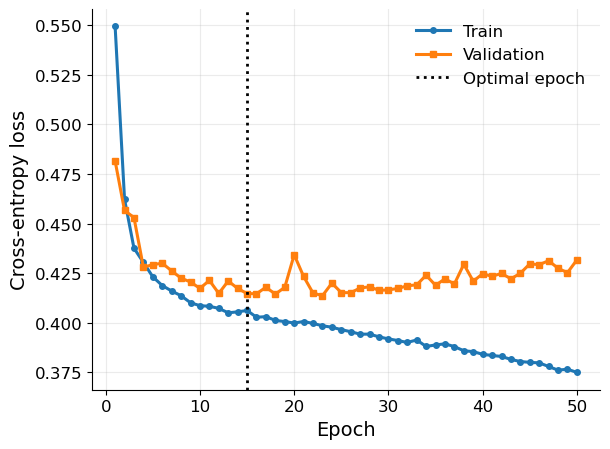

In [24]:
# Training / validation loss curves
import matplotlib.pyplot as plt

def plot_loss_curves(history, title=None, outpath=None, best_epoch=None):
    fig, ax = plt.subplots(figsize=(6.2, 4.6))
    ax.plot(history["epoch"], history["train_loss"], label="Train", linewidth=2.2, marker="o", markersize=4)
    ax.plot(history["epoch"], history["val_loss"], label="Validation", linewidth=2.2, marker="s", markersize=4)

    if best_epoch is not None:
        ax.axvline(best_epoch, linestyle=":", linewidth=2.0, color="black", label=f"Optimal epoch")

    ax.set_xlabel("Epoch", fontsize=14)
    ax.set_ylabel("Cross-entropy loss", fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=15)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, fontsize=12)

    plt.tight_layout()
    if outpath is not None:
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

plot_loss_curves(hist_treat, outpath="Figs/FigS1.pdf", best_epoch=best_epoch+1)

## 5. Original test-set results

In [14]:
# Build fixed prediction cache on the ORIGINAL test set
#   - LSTM, LR, RF, GBDT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

required_names = [
    "df_train", "df_val", "df_test",
    "model_treat", "device",
    "generate_dataset_from_dataframe", "collect_week_level_predictions",
    "compute_patient_complexity_from_weekly", "compute_cis_weights",
    "build_week_level_tabular"
]
missing = [x for x in required_names if x not in globals()]
if len(missing) > 0:
    raise RuntimeError(f"Missing required notebook objects/functions: {missing}")

def weighted_brier_local(y_true, y_prob, w=None):
    y_true = np.asarray(y_true).astype(float)
    y_prob = np.asarray(y_prob).astype(float)
    if w is None:
        return float(np.mean((y_prob - y_true) ** 2))
    w = np.asarray(w).astype(float)
    w = w / (w.sum() + 1e-12)
    return float(np.sum(w * (y_prob - y_true) ** 2))

def compute_metrics_local(y_true, y_prob, sample_weight=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return {"auroc": np.nan, "auprc": np.nan, "brier": np.nan, "n": int(len(y_true))}

    return {
        "auroc": float(roc_auc_score(y_true, y_prob, sample_weight=sample_weight)),
        "auprc": float(average_precision_score(y_true, y_prob, sample_weight=sample_weight)),
        "brier": float(weighted_brier_local(y_true, y_prob, w=sample_weight)),
        "n": int(len(y_true)),
    }

df_train_ref = df_train.copy().reset_index(drop=True)
pe_train_ref = compute_patient_complexity_from_weekly(df_train_ref)

df_test_pool = df_test.copy().reset_index(drop=True)
pe_test_pool = compute_patient_complexity_from_weekly(df_test_pool)
cis_test_pool = compute_cis_weights(df_test_pool)
df_test_pool["_cis_score"] = cis_test_pool

rank_score = pd.Series(df_test_pool["_cis_score"]).rank(method="first")
df_test_pool["_complexity_bin"] = (
    pd.qcut(rank_score, q=5, labels=[1, 2, 3, 4, 5]).astype(int)
)


def attach_pid_row_map(entry):
    pid = np.asarray(entry["pid"], dtype=int)
    pid_to_rows = {}
    for p in np.unique(pid):
        pid_to_rows[int(p)] = np.where(pid == p)[0]
    entry["_pid_to_rows"] = pid_to_rows
    return entry

prediction_cache = {}

# LSTM
treat_ds_full = generate_dataset_from_dataframe(
    df_test_pool,
    miss_value=2, future_window=1, prev_week_mode=2,
    include_treat_stats=True, include_tlstm_treat=True, daily_treatment=True
)

y_lstm_full, p_lstm_full, sidx_lstm_full = collect_week_level_predictions(
    model_treat, treat_ds_full, include_tlstm_treat=True, device=device
)

prediction_cache["LSTM"] = attach_pid_row_map({
    "model": "LSTM",
    "kind": "lstm",
    "y": np.asarray(y_lstm_full, dtype=int),
    "p": np.asarray(p_lstm_full, dtype=float),
    "pid": np.asarray(sidx_lstm_full, dtype=int),
})

# Tabular models
X_tr_tx, y_tr_tx, pid_tr_tx, _ = build_week_level_tabular(
    df_train_ref, include_treat=True, include_dose=True
)
X_te_tx, y_te_tx, pid_te_tx, _ = build_week_level_tabular(
    df_test_pool, include_treat=True, include_dose=True
)

tabular_models = [
    (
        "LR",
        Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
        ]),
        X_tr_tx, y_tr_tx, X_te_tx, y_te_tx, pid_te_tx
    ),
    (
        "RF",
        RandomForestClassifier(
            n_estimators=300, random_state=42,
            class_weight="balanced_subsample", n_jobs=-1
        ),
        X_tr_tx, y_tr_tx, X_te_tx, y_te_tx, pid_te_tx
    ),
    (
        "GBDT",
        GradientBoostingClassifier(random_state=42),
        X_tr_tx, y_tr_tx, X_te_tx, y_te_tx, pid_te_tx
    ),
]

for name, clf, Xtr, ytr, Xte, yte, pidte in tabular_models:
    clf.fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]
    prediction_cache[name] = attach_pid_row_map({
        "model": name,
        "kind": "tabular",
        "y": np.asarray(yte, dtype=int),
        "p": np.asarray(prob, dtype=float),
        "pid": np.asarray(pidte, dtype=int),
    })

print("Built prediction cache for:")
print(list(prediction_cache.keys()))

baseline_rows = []
for model_name, entry in prediction_cache.items():
    m_plain = compute_metrics_local(entry["y"], entry["p"], sample_weight=None)
    w_full = df_test_pool["_cis_score"].to_numpy()[entry["pid"]]
    m_w = compute_metrics_local(entry["y"], entry["p"], sample_weight=w_full)

    baseline_rows.append({
        "model": model_name,
        "plain_auroc_full": m_plain["auroc"],
        "cis_auroc_full": m_w["auroc"],
        "plain_auprc_full": m_plain["auprc"],
        "cis_auprc_full": m_w["auprc"],
        "plain_brier_full": m_plain["brier"],
        "cis_brier_full": m_w["brier"],
        "AUROC gap": m_plain["auroc"] - m_w["auroc"],
        "AUPRC gap": m_plain["auprc"] - m_w["auprc"],
        "Brier gap": m_w["brier"] - m_plain["brier"],
    })

baseline_df = (
    pd.DataFrame(baseline_rows)
    .sort_values("plain_auroc_full", ascending=False)
    .reset_index(drop=True)
)
print("Results for Table 1")
display(baseline_df)

Built prediction cache for:
['LSTM', 'LR', 'RF', 'GBDT']
Results for Table 1


,model,plain_auroc_full,cis_auroc_full,plain_auprc_full,cis_auprc_full,plain_brier_full,cis_brier_full,AUROC gap,AUPRC gap,Brier gap
0,LSTM,0.896804,0.835580,0.946442,0.902896,0.126618,0.165408,0.061224,0.043546,0.038790
1,GBDT,0.895096,0.832300,0.946251,0.902005,0.124497,0.161136,0.062796,0.044245,0.036639
2,LR,0.887538,0.823141,0.938824,0.892611,0.133810,0.173653,0.064397,0.046212,0.039843
3,RF,0.883073,0.818261,0.940094,0.892293,0.131603,0.167120,0.064812,0.047800,0.035518


In [15]:
# exact class counts on the original held-out test set
entry = prediction_cache["LSTM"]   # or any model; y is the same label vector
y = np.asarray(entry["y"], dtype=int)
n_pos = int((y == 1).sum())
n_neg = int((y == 0).sum())
print(n_pos, n_neg, n_pos / len(y))

n_pos = int((y_tr_tx == 1).sum())
n_neg = int((y_tr_tx == 0).sum())

print(f"Positive samples: {n_pos}")
print(f"Negative samples: {n_neg}")
print(f"Event prevalence: {n_pos / len(y_tr_tx):.4f}")

4993 2707 0.6484415584415585
Positive samples: 19596
Negative samples: 11284
Event prevalence: 0.6346


Results for gamma = 0.5


,gamma,model,AUROC gap,AUPRC gap,Brier gap
0,0.5,LSTM,0.023283,0.015516,0.015805
1,0.5,GBDT,0.023958,0.015836,0.014982
2,0.5,LR,0.024686,0.016584,0.016363
3,0.5,RF,0.024947,0.017181,0.014606


Results for gamma = 1


,gamma,model,AUROC gap,AUPRC gap,Brier gap
0,1,LSTM,0.043496,0.030218,0.028467
1,1,GBDT,0.044689,0.030773,0.026948
2,1,LR,0.045943,0.032188,0.029354
3,1,RF,0.046291,0.033305,0.026181


Results for gamma = 1.5


,gamma,model,AUROC gap,AUPRC gap,Brier gap
0,1.5,LSTM,0.061224,0.043546,0.038790
1,1.5,GBDT,0.062796,0.044245,0.036639
2,1.5,LR,0.064397,0.046212,0.039843
3,1.5,RF,0.064812,0.047800,0.035518


Results for gamma = 2


,gamma,model,AUROC gap,AUPRC gap,Brier gap
0,2,LSTM,0.076751,0.055432,0.047319
1,2,GBDT,0.078589,0.056193,0.044585
2,2,LR,0.080387,0.058598,0.048413
3,2,RF,0.080890,0.060629,0.043148


Results for gamma = 5


,gamma,model,AUROC gap,AUPRC gap,Brier gap
0,5,LSTM,0.141786,0.105388,0.078943
1,5,GBDT,0.144158,0.105322,0.073258
2,5,LR,0.145225,0.108832,0.078885
3,5,RF,0.147013,0.113543,0.070558


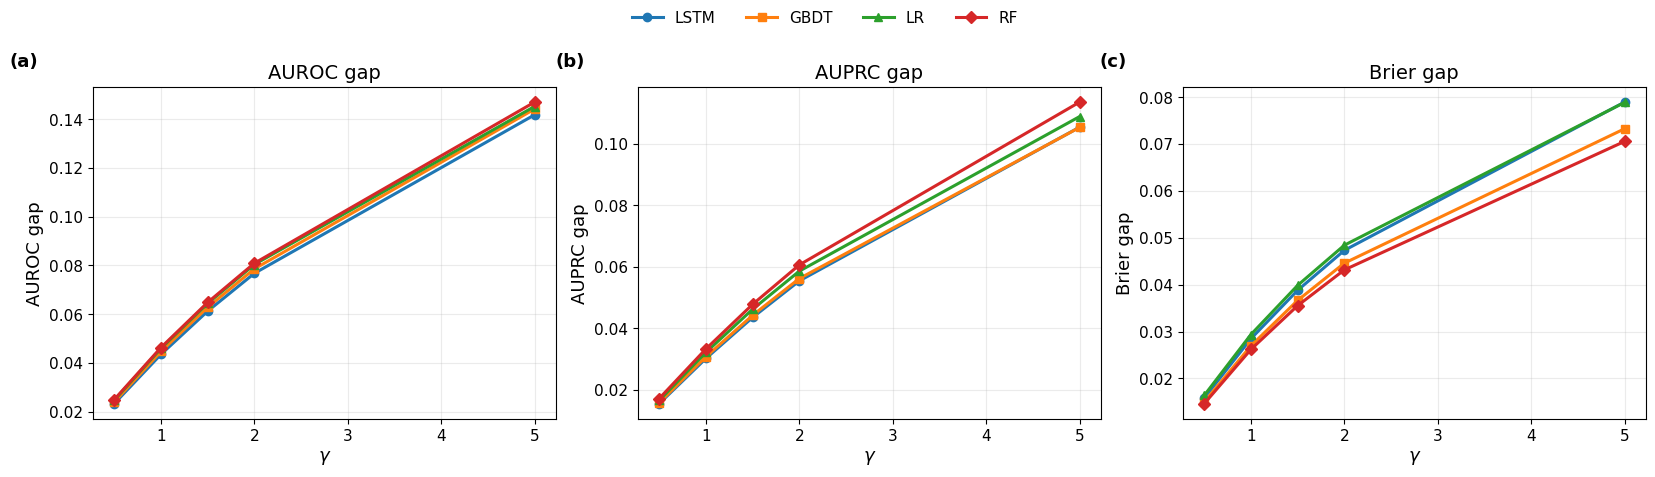

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gamma_list = [0.5, 1, 1.5, 2, 5]
model_order = ["LSTM", "GBDT", "LR", "RF"]

all_rows = []

for gamma in gamma_list:

    # compute CIS / CIS weights on the original test pool
    cis_test_pool = compute_cis_weights(df_test_pool, gamma=gamma)
    df_test_pool["_cis_score"] = cis_test_pool

    baseline_rows = []
    for model_name, entry in prediction_cache.items():
        if model_name not in model_order:
            continue

        m_plain = compute_metrics_local(entry["y"], entry["p"], sample_weight=None)
        w_full = df_test_pool["_cis_score"].to_numpy()[entry["pid"]]
        m_w = compute_metrics_local(entry["y"], entry["p"], sample_weight=w_full)

        baseline_rows.append({
            "gamma": gamma,
            "model": model_name,
            "AUROC gap": m_plain["auroc"] - m_w["auroc"],
            "AUPRC gap": m_plain["auprc"] - m_w["auprc"],
            "Brier gap": m_w["brier"] - m_plain["brier"],
        })

    baseline_df = pd.DataFrame(baseline_rows)

    # enforce model order
    baseline_df["model"] = pd.Categorical(
        baseline_df["model"], categories=model_order, ordered=True
    )
    baseline_df = baseline_df.sort_values("model").reset_index(drop=True)

    print(f"Results for gamma = {gamma}")
    display(baseline_df)

    all_rows.append(baseline_df)

# Combine all results
gap_df = pd.concat(all_rows, ignore_index=True)

# Plot settings
color_map = {
    "LSTM": "#1f77b4",
    "GBDT": "#ff7f0e",
    "LR": "#2ca02c",
    "RF": "#d62728",
}
marker_map = {
    "LSTM": "o",
    "GBDT": "s",
    "LR": "^",
    "RF": "D",
}

# Combined 3-panel figure: AUROC / AUPRC / Brier gaps vs gamma
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), sharex=True)

metric_specs = [
    ("AUROC gap", "AUROC gap", "(a)"),
    ("AUPRC gap", "AUPRC gap", "(b)"),
    ("Brier gap", "Brier gap", "(c)")
]

for ax, (metric_col, ylab, panel_tag) in zip(axes, metric_specs):
    for model in model_order:
        sub = gap_df[gap_df["model"] == model].sort_values("gamma")
        if sub.empty:
            continue

        x_vals = sub["gamma"].to_numpy(dtype=float)
        y_vals = sub[metric_col].to_numpy(dtype=float)

        ax.plot(
            x_vals, y_vals,
            label=model,
            color=color_map[model],
            marker=marker_map[model],
            linewidth=2.2,
            markersize=6
        )

    ax.set_xlabel(r"$\gamma$", fontsize=13)
    ax.set_ylabel(ylab, fontsize=13)
    ax.set_title(ylab, fontsize=14)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, alpha=0.25)

    # optional panel label
    ax.text(-0.18, 1.05, panel_tag, transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="bottom")

# Shared legend for the full figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    # title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=4,
    frameon=False,
    fontsize=11,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("Figs/FigSX_gamma_gap_3panel.pdf", dpi=300, bbox_inches="tight")
plt.show()

Results for D = 3


,D,model,AUROC gap,AUPRC gap,Brier gap
0,3,LSTM,0.061224,0.043546,0.038790
1,3,GBDT,0.062796,0.044245,0.036639
2,3,LR,0.064397,0.046212,0.039843
3,3,RF,0.064812,0.047800,0.035518


Results for D = 4


,D,model,AUROC gap,AUPRC gap,Brier gap
0,4,LSTM,0.065942,0.047608,0.041404
1,4,GBDT,0.067325,0.048295,0.038904
2,4,LR,0.069378,0.050097,0.042547
3,4,RF,0.069441,0.052363,0.037737


Results for D = 5


...

,D,model,AUROC gap,AUPRC gap,Brier gap
0,8,LSTM,0.048567,0.038841,0.031433
1,8,GBDT,0.050192,0.039922,0.030444
2,8,LR,0.052332,0.041536,0.033018
3,8,RF,0.051040,0.043040,0.029717


Results for D = 9


,D,model,AUROC gap,AUPRC gap,Brier gap
0,9,LSTM,0.043409,0.035540,0.028390
1,9,GBDT,0.044900,0.036553,0.027656
2,9,LR,0.046829,0.038108,0.029826
3,9,RF,0.045799,0.039456,0.027177


Results for D = 10


,D,model,AUROC gap,AUPRC gap,Brier gap
0,10,LSTM,0.039059,0.032633,0.025780
1,10,GBDT,0.040394,0.033559,0.025214
2,10,LR,0.042128,0.035045,0.027046
3,10,RF,0.041333,0.036254,0.024936


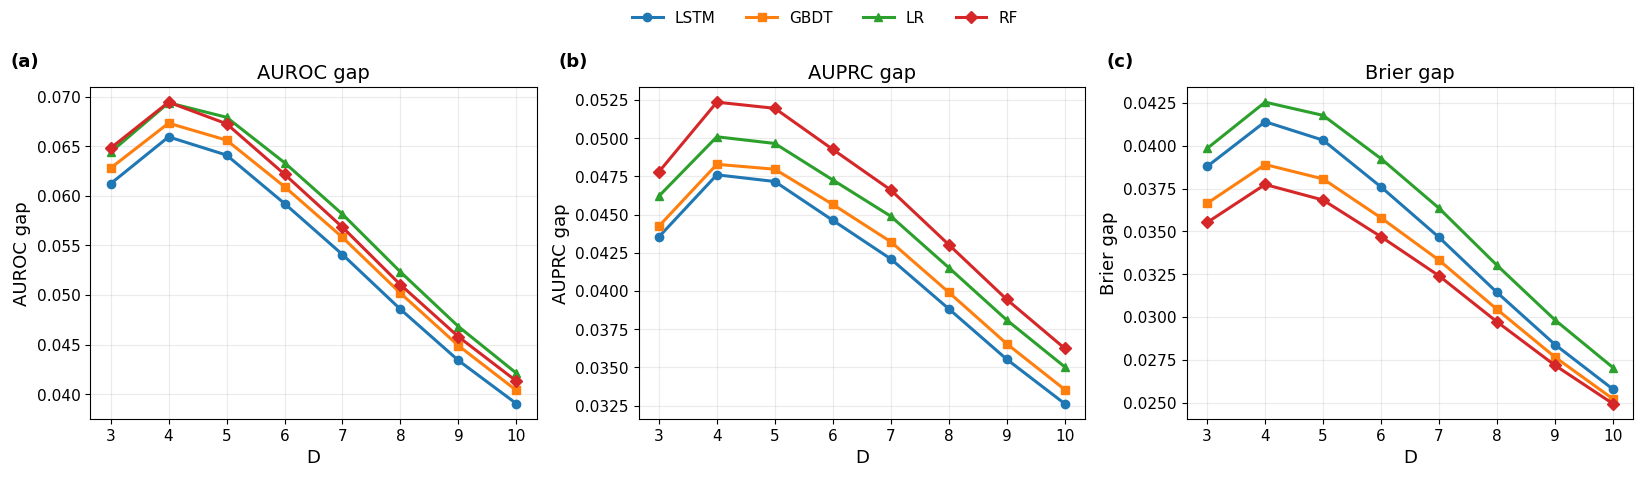

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

D_list = [3, 4, 5, 6, 7, 8, 9, 10]
model_order = ["LSTM", "GBDT", "LR", "RF"]

all_rows = []

for D in D_list:

    # compute CIS / CIS weights on the original test pool
    cis_test_pool = compute_cis_weights(df_test_pool, D=D)
    df_test_pool["_cis_score"] = cis_test_pool

    baseline_rows = []
    for model_name, entry in prediction_cache.items():
        if model_name not in model_order:
            continue

        m_plain = compute_metrics_local(entry["y"], entry["p"], sample_weight=None)
        w_full = df_test_pool["_cis_score"].to_numpy()[entry["pid"]]
        m_w = compute_metrics_local(entry["y"], entry["p"], sample_weight=w_full)

        baseline_rows.append({
            "D": D,
            "model": model_name,
            "AUROC gap": m_plain["auroc"] - m_w["auroc"],
            "AUPRC gap": m_plain["auprc"] - m_w["auprc"],
            "Brier gap": m_w["brier"] - m_plain["brier"],
        })

    baseline_df = pd.DataFrame(baseline_rows)

    # enforce model order
    baseline_df["model"] = pd.Categorical(
        baseline_df["model"], categories=model_order, ordered=True
    )
    baseline_df = baseline_df.sort_values("model").reset_index(drop=True)

    print(f"Results for D = {D}")
    display(baseline_df)

    all_rows.append(baseline_df)

# Combine all results
gap_df = pd.concat(all_rows, ignore_index=True)

# Plot settings
color_map = {
    "LSTM": "#1f77b4",
    "GBDT": "#ff7f0e",
    "LR": "#2ca02c",
    "RF": "#d62728",
}
marker_map = {
    "LSTM": "o",
    "GBDT": "s",
    "LR": "^",
    "RF": "D",
}

# Combined 3-panel figure: AUROC / AUPRC / Brier gaps vs D
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), sharex=True)

metric_specs = [
    ("AUROC gap", "AUROC gap", "(a)"),
    ("AUPRC gap", "AUPRC gap", "(b)"),
    ("Brier gap", "Brier gap", "(c)")
]

for ax, (metric_col, ylab, panel_tag) in zip(axes, metric_specs):
    for model in model_order:
        sub = gap_df[gap_df["model"] == model].sort_values("D")
        if sub.empty:
            continue

        x_vals = sub["D"].to_numpy(dtype=float)
        y_vals = sub[metric_col].to_numpy(dtype=float)

        ax.plot(
            x_vals, y_vals,
            label=model,
            color=color_map[model],
            marker=marker_map[model],
            linewidth=2.2,
            markersize=6
        )

    ax.set_xlabel("D", fontsize=13)
    ax.set_ylabel(ylab, fontsize=13)
    ax.set_title(ylab, fontsize=14)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, alpha=0.25)

    # optional panel label
    ax.text(-0.18, 1.05, panel_tag, transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="bottom")

# Shared legend for the full figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    # title="Model",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=4,
    frameon=False,
    fontsize=11,
    title_fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("Figs/FigSY_D_gap_3panel.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
import numpy as np
import pandas as pd

# 1) continuous patient-level complexity score on train-ref and test
train_complexity_score = pd.Series(
    compute_patient_complexity_from_weekly(df_train_ref),
    index=df_train_ref.index,
    dtype=float
)

test_complexity_score = pd.Series(
    compute_patient_complexity_from_weekly(df_test_pool),
    index=df_test_pool.index,
    dtype=float
)

# 2) define fixed cutpoints from the TRAIN reference distribution
#    These are thresholds, not equal-frequency bins on the test set.
cutpoints = np.quantile(train_complexity_score.dropna(), [0.2, 0.4, 0.6, 0.8])

# 3) apply those fixed cutpoints to the ORIGINAL test set
#    This will usually produce an uneven distribution.
bins = [-np.inf, cutpoints[0], cutpoints[1], cutpoints[2], cutpoints[3], np.inf]
labels = [1, 2, 3, 4, 5]

df_test_pool["_complexity_score_raw"] = test_complexity_score.values

### Figure 2: Benchmark complexity distribution

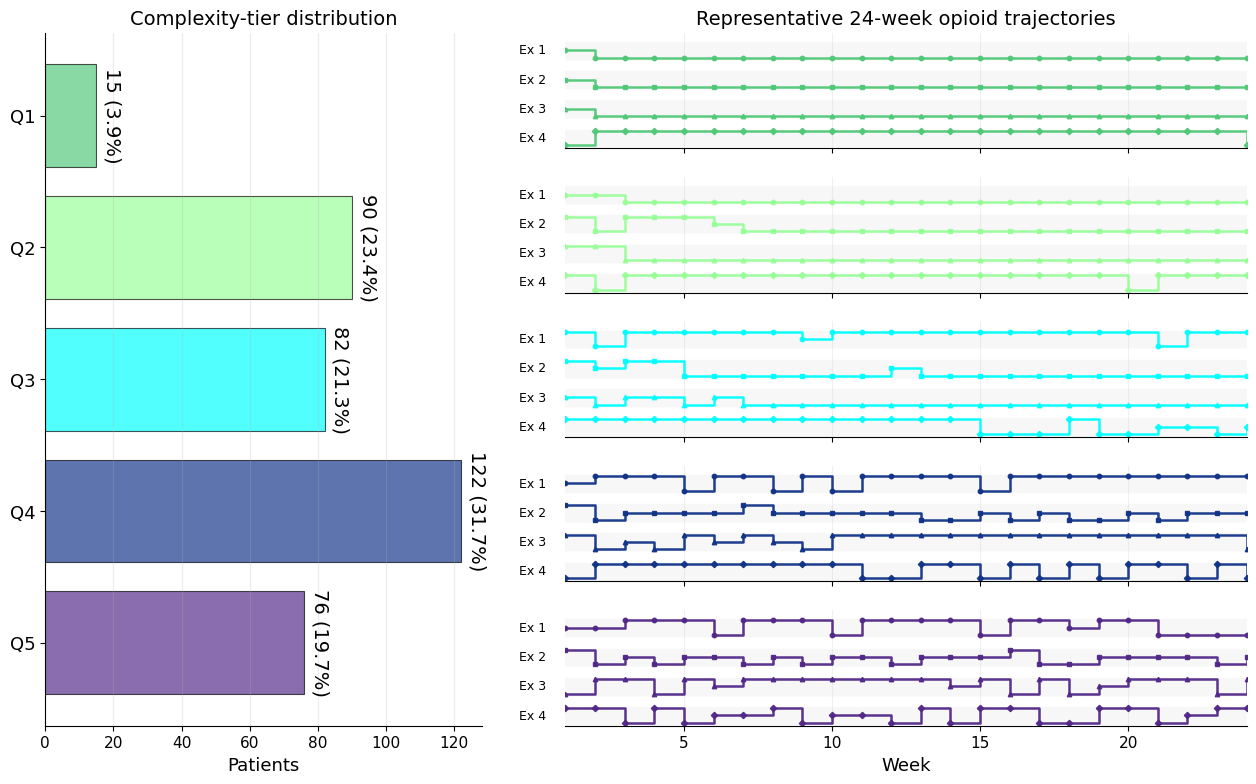

In [19]:
# Left: horizontal tier bars
# Right: example 24-week opioid trajectories shown as subbands within each tier
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# 1) Select dataframe
if "df_test_pool" in globals():
    plot_df = df_test_pool.copy()
elif "df_test" in globals():
    plot_df = df_test.copy()
else:
    raise RuntimeError("Need df_test_pool or df_test in memory before plotting Figure 2.")

if "Target_Permutation_Entropy" in plot_df.columns:
    tier_col = "Target_Permutation_Entropy"
elif "_complexity_bin_real" in plot_df.columns:
    tier_col = "_complexity_bin_real"
else:
    raise RuntimeError("Could not find a tier column.")

# 2) Detect opioid weekly columns
opioid_cols = [c for c in plot_df.columns if re.match(r"Opioid_week\d+$", c)]
if len(opioid_cols) == 0:
    raise RuntimeError("No columns like 'Opioid_week0', 'Opioid_week1', ... were found.")

opioid_cols = sorted(opioid_cols, key=lambda x: int(re.findall(r"(\d+)$", x)[0]))
n_weeks = len(opioid_cols)

plot_df = plot_df.loc[plot_df[tier_col].notna()].copy()
plot_df[tier_col] = plot_df[tier_col].astype(int)

# 3) Tier summary
tier_order = [1, 2, 3, 4, 5]
tier_labels = [f"Q{i}" for i in tier_order]
tier_colors = ['#50C878', '#98FF98', '#00FFFF', '#113388', '#512888']

tier_counts = np.array([(plot_df[tier_col] == q).sum() for q in tier_order], dtype=int)
tier_perc = 100 * tier_counts / tier_counts.sum()

# 4) Choose example trajectories per tier
rng = np.random.default_rng(42)
n_examples_per_tier = 4

example_rows = {}
for q in tier_order:
    idx = plot_df.index[plot_df[tier_col] == q].to_numpy()
    if len(idx) == 0:
        example_rows[q] = np.array([], dtype=int)
    elif len(idx) <= n_examples_per_tier:
        example_rows[q] = idx
    else:
        example_rows[q] = rng.choice(idx, size=n_examples_per_tier, replace=False)

# 5) Helper: force trajectory states into 0/1/2
#    0 = negative, 1 = positive, 2 = missing
def recode_opioid_states(seq):
    arr = pd.to_numeric(pd.Series(seq), errors="coerce").to_numpy(dtype=float)

    # initialize everything as missing
    rec = np.full(arr.shape, 2, dtype=int)

    # current coding:
    #   -1 = negative
    #    1 = positive
    # everything else (including NaN) stays as missing = 2
    rec[arr == -1] = 0
    rec[arr == 1] = 1

    return rec

# 6) Plot
fig = plt.figure(figsize=(15.5, 9.0))
gs = GridSpec(
    nrows=5, ncols=2,
    width_ratios=[2.05, 3.20],
    height_ratios=[1, 1, 1, 1, 1],
    wspace=0.15, hspace=0.25
)

# Left panel: tier distribution
ax_bar = fig.add_subplot(gs[:, 0])

ypos = np.arange(len(tier_order))
bars = ax_bar.barh(
    ypos, tier_counts,
    color=tier_colors,
    edgecolor="black",
    linewidth=0.8,
    height=0.78,
    alpha=0.68
)

ax_bar.set_yticks(ypos)
ax_bar.set_yticklabels(tier_labels, fontsize=13)
ax_bar.invert_yaxis()
ax_bar.set_xlabel("Patients", fontsize=13)
ax_bar.set_title("Complexity-tier distribution", fontsize=14)
ax_bar.tick_params(axis="x", labelsize=11)
ax_bar.grid(axis="x", alpha=0.25)

# rotate percentage labels to save space
x_pad = max(tier_counts) * 0.015
for y, c, p in zip(ypos, tier_counts, tier_perc):
    ax_bar.text(
        c + x_pad,
        y,
        f"{c} ({p:.1f}%)",
        rotation=-90,
        va="center",
        ha="left",
        fontsize=14
    )

ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# Right panel: example trajectories by tier
# Each tier gets one axis, and within it each example gets its own subband
# traj_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
traj_markers = ["o", "s", "^", "D", "P", "X"]

right_axes = []

for i, q in enumerate(tier_order):
    sharex_ax = right_axes[0] if len(right_axes) > 0 else None
    ax = fig.add_subplot(gs[i, 1], sharex=sharex_ax)
    right_axes.append(ax)

    selected = example_rows[q]
    n_sel = len(selected)

    # layout for subbands
    row_height = 3.0     # for the 3 state levels 0/1/2
    row_gap = 1.0
    block_height = row_height + row_gap

    # total y span
    y_max = max(1, n_examples_per_tier) * block_height - row_gap

    # light separators / subband backgrounds
    for j in range(n_examples_per_tier):
        base = (n_examples_per_tier - 1 - j) * block_height
        ax.axhspan(base - 0.15, base + 2.15, color="0.97", zorder=0)
        ax.hlines(base - 0.15, 1, n_weeks, color="0.90", linewidth=0.8, zorder=0)

    # plot selected trajectories
    for j, row_id in enumerate(selected):
        seq = recode_opioid_states(plot_df.loc[row_id, opioid_cols])
        x = np.arange(1, n_weeks + 1)

        base = (n_examples_per_tier - 1 - j) * block_height
        y = seq + base

        ax.step(
            x, y,
            where="post",
            color = tier_colors[i],#traj_colors[j % len(traj_colors)],
            linewidth=1.8,
            alpha=0.95
        )
        ax.plot(
            x, y,
            linestyle="None",
            marker=traj_markers[j % len(traj_markers)],
            markersize=3.2,
            color = tier_colors[i],#traj_colors[j % len(traj_colors)],
            alpha=0.95
        )

        # label each example row
        ax.text(
            0.35, base + 1.0,
            f"Ex {j+1}",
            fontsize=9,
            ha="right",
            va="center"
            # color = tier_colors[i]#traj_colors[j % len(traj_colors)]
        )

    ax.set_ylim(-0.4, y_max + 0.4)
    ax.set_xlim(1, n_weeks)

    # remove crowded y-axis
    ax.set_yticks([])
    ax.tick_params(axis="y", length=0)

    ax.grid(axis="x", alpha=0.18)

    if i < len(tier_order) - 1:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Week", fontsize=13)
        ax.tick_params(axis="x", labelsize=11)

    if i == 0:
        ax.set_title(
            "Representative 24-week opioid trajectories",
            # "(state levels within each row: 0 = negative, 1 = positive, 2 = missing)",
            fontsize=14
        )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig("Figs/Figure2_revised_distribution_plus_examples.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Figure 3: Tier-specific LSTM performance on the original test set

LSTM tier-specific performance on the full original test set:


,tier,n_weeks,positive_rate,auroc,auprc,brier
0,Q1,300,0.676667,0.987482,0.992520,0.019580
1,Q2,1800,0.710556,0.968873,0.986842,0.046485
2,Q3,1640,0.676220,0.938875,0.973502,0.091919
3,Q4,2440,0.595492,0.840818,0.899361,0.159884
4,Q5,1520,0.624342,0.700970,0.799690,0.226676


[0.98748159 0.96887339 0.93887454 0.84081776 0.70097014]
[0.99252015 0.98684232 0.97350202 0.89936057 0.79968967]


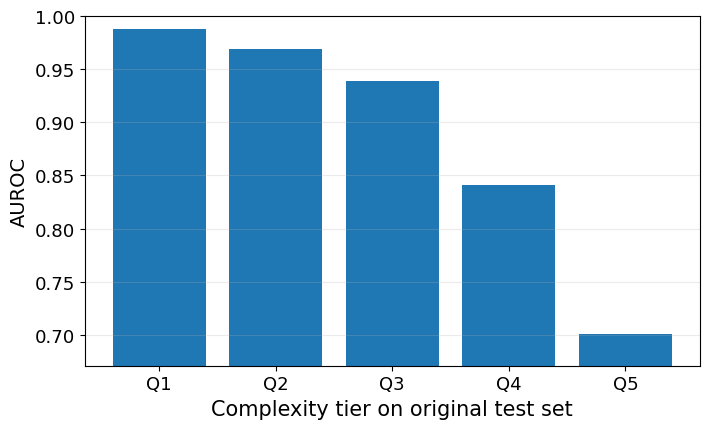

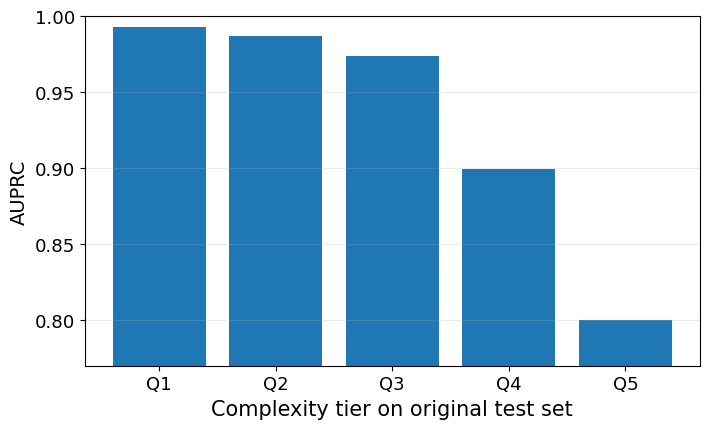

In [20]:
#   1) LSTM performance by pure complexity tier (Q1..Q5), independent of cohorts
#   2) LSTM plain vs CIS-weighted performance on the full original test set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

axis_label_fs = 14
tick_fs = 13
title_fs = 15

# Safety checks
required_names = ["prediction_cache", "df_test_pool", "compute_metrics_local"]
missing = [x for x in required_names if x not in globals()]
if len(missing) > 0:
    raise RuntimeError(f"Missing required objects from previous cells: {missing}")

if "LSTM" not in prediction_cache:
    raise RuntimeError("prediction_cache['LSTM'] not found. Please run the previous cells first.")

lstm_entry = prediction_cache["LSTM"]
y_full = np.asarray(lstm_entry["y"], dtype=int)
p_full = np.asarray(lstm_entry["p"], dtype=float)
pid_full = np.asarray(lstm_entry["pid"], dtype=int)

# patient-level tier / weight mapped to week-level rows
tier_full = df_test_pool["Target_Permutation_Entropy"].to_numpy().astype(int)[pid_full]
cis_w_full = df_test_pool["_cis_score"].to_numpy()[pid_full]

# 1) Pure tier-specific performance on the ORIGINAL dataset
tier_rows = []
for q in [1, 2, 3, 4, 5]:
    mask = (tier_full == q)
    y_q = y_full[mask]
    p_q = p_full[mask]

    m_q = compute_metrics_local(y_q, p_q, sample_weight=None)

    tier_rows.append({
        "tier": f"Q{q}",
        "n_weeks": int(mask.sum()),
        "positive_rate": float(np.mean(y_q)) if len(y_q) > 0 else np.nan,
        "auroc": m_q["auroc"],
        "auprc": m_q["auprc"],
        "brier": m_q["brier"],
    })

tier_perf_df = pd.DataFrame(tier_rows)
print("LSTM tier-specific performance on the full original test set:")
display(tier_perf_df)

# AUROC by tier
fig, ax = plt.subplots(figsize=(7.2, 4.4))
x = np.arange(tier_perf_df.shape[0])
vals = tier_perf_df["auroc"].to_numpy(dtype=float)

ax.bar(x, vals)
ax.set_xticks(x)
ax.set_xticklabels(tier_perf_df["tier"].tolist(), fontsize=tick_fs)
ax.tick_params(axis="y", labelsize=tick_fs)
ax.set_ylabel("AUROC", fontsize=axis_label_fs)
ax.set_xlabel("Complexity tier on original test set", fontsize=title_fs)
finite_vals = vals[np.isfinite(vals)]
if len(finite_vals) > 0:
    ax.set_ylim(max(0.0, float(finite_vals.min()) - 0.03), min(1.0, float(finite_vals.max()) + 0.03))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig('Figs/Figure3a.pdf')
print(vals)

# AUPRC by tier
fig, ax = plt.subplots(figsize=(7.2, 4.4))
x = np.arange(tier_perf_df.shape[0])
vals = tier_perf_df["auprc"].to_numpy(dtype=float)

ax.bar(x, vals)
ax.set_xticks(x)
ax.set_xticklabels(tier_perf_df["tier"].tolist(), fontsize=tick_fs)
ax.tick_params(axis="y", labelsize=tick_fs)
ax.set_ylabel("AUPRC", fontsize=axis_label_fs)
ax.set_xlabel("Complexity tier on original test set", fontsize=title_fs)
finite_vals = vals[np.isfinite(vals)]
if len(finite_vals) > 0:
    ax.set_ylim(max(0.0, float(finite_vals.min()) - 0.03), min(1.0, float(finite_vals.max()) + 0.03))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig('Figs/Figure3b.pdf')
print(vals)
# 2) Full original dataset: plain vs CIS-weighted
m_plain_full = compute_metrics_local(y_full, p_full, sample_weight=None)
m_cis_full = compute_metrics_local(y_full, p_full, sample_weight=cis_w_full)

orig_compare_df = pd.DataFrame([
    {
        "score_type": "Plain",
        "auroc": m_plain_full["auroc"],
        "auprc": m_plain_full["auprc"],
        "brier": m_plain_full["brier"],
    },
    {
        "score_type": "CIS-weighted",
        "auroc": m_cis_full["auroc"],
        "auprc": m_cis_full["auprc"],
        "brier": m_cis_full["brier"],
    }
])

## 6. Cohort-resampling results and Figure 4

In [21]:
# Complexity-based resampling design
#   5 cohorts with gradually increased bimodal low+high composition
#   Target compositions:
#     C1 = [0,10,80,10,0]
#     C2 = [5,15,60,15,5]
#     C3 = [20,10,40,10,20]
#     C4 = [30,10,20,10,30]
#     C5 = [40,10,0,10,40]
#   Search objective:
#     - keep anchor-model plain AUROC similar
#     - match target composition

import numpy as np
import pandas as pd

def build_sampled_patient_df(df_pool, sampled_ids):
    sampled_df = df_pool.iloc[sampled_ids].copy().reset_index(drop=True)
    if "who" in sampled_df.columns:
        sampled_df["_orig_who"] = sampled_df["who"].values
        sampled_df["who"] = np.arange(len(sampled_df), dtype=int)
    return sampled_df

def materialize_sample_from_cache(cache_entry, sampled_patient_ids):
    y_parts, p_parts, pid_new_parts = [], [], []

    for new_pid, orig_pid in enumerate(sampled_patient_ids):
        rows = cache_entry["_pid_to_rows"][int(orig_pid)]
        y_parts.append(cache_entry["y"][rows])
        p_parts.append(cache_entry["p"][rows])
        pid_new_parts.append(np.full(len(rows), new_pid, dtype=int))

    y_sub = np.concatenate(y_parts)
    p_sub = np.concatenate(p_parts)
    pid_new = np.concatenate(pid_new_parts)
    return y_sub, p_sub, pid_new

def evaluate_sampled_cohort(cache_entry, sampled_patient_ids, sampled_df, df_train_ref, pe_train_ref, gamma=1.5):
    y_sub, p_sub, pid_new = materialize_sample_from_cache(cache_entry, sampled_patient_ids)

    pe_sample = compute_patient_complexity_from_weekly(sampled_df)
    cis_sample = compute_cis_weights(sampled_df, gamma=gamma)
    w_sub = cis_sample[pid_new]

    m_plain = compute_metrics_local(y_sub, p_sub, sample_weight=None)
    m_w = compute_metrics_local(y_sub, p_sub, sample_weight=w_sub)

    return {
        "plain_auroc": m_plain["auroc"],
        "plain_auprc": m_plain["auprc"],
        "plain_brier": m_plain["brier"],
        "cis_auroc": m_w["auroc"],
        "cis_auprc": m_w["auprc"],
        "cis_brier": m_w["brier"],
        "n_weeks": m_plain["n"],
    }

def sample_patients_by_bin(df_pool, target_probs, n_patients, rng):
    bins = np.array([1, 2, 3, 4, 5], dtype=int)
    target_probs = np.asarray(target_probs, dtype=float)
    target_probs = target_probs / target_probs.sum()

    counts = rng.multinomial(n_patients, target_probs)

    sampled_ids = []
    for b, cnt in zip(bins, counts):
        ids_b = np.where(df_pool["_complexity_bin"].to_numpy() == b)[0]
        replace = cnt > len(ids_b)
        if cnt > 0:
            take = rng.choice(ids_b, size=cnt, replace=replace)
            sampled_ids.extend(take.tolist())

    sampled_ids = np.asarray(sampled_ids, dtype=int)
    rng.shuffle(sampled_ids)
    return sampled_ids

def get_observed_bin_fraction(df_sample):
    frac = (
        df_sample["_complexity_bin"]
        .value_counts(normalize=True)
        .sort_index()
        .reindex([1,2,3,4,5], fill_value=0.0)
        .to_numpy(dtype=float)
    )
    return frac

def search_matched_cohort(
    df_pool,
    cache_entry_anchor,
    df_train_ref,
    pe_train_ref,
    target_probs,
    n_patients,
    target_plain_auroc,
    n_trials=800,
    seed=123,
    auroc_tol=0.008,
    comp_weight=0.25,
):
    rng = np.random.default_rng(seed)

    best = None
    best_obj = np.inf

    for t in range(n_trials):
        sampled_ids = sample_patients_by_bin(df_pool, target_probs, n_patients=n_patients, rng=rng)
        sampled_df = build_sampled_patient_df(df_pool, sampled_ids)

        observed_frac = get_observed_bin_fraction(sampled_df)

        m_anchor = evaluate_sampled_cohort(
            cache_entry_anchor, sampled_ids, sampled_df, df_train_ref, pe_train_ref
        )

        if np.isnan(m_anchor["plain_auroc"]):
            continue

        plain_err = abs(m_anchor["plain_auroc"] - target_plain_auroc)
        comp_err = float(np.abs(observed_frac - np.asarray(target_probs)).sum())

        obj = plain_err + comp_weight * comp_err

        if obj < best_obj:
            best_obj = obj
            best = {
                "sampled_ids": sampled_ids,
                "sampled_df": sampled_df,
                "anchor_metrics": m_anchor,
                "observed_bin_frac": observed_frac,
                "objective": obj,
                "plain_err": plain_err,
                "comp_err": comp_err,
            }

            if plain_err <= auroc_tol and comp_err <= 0.08:
                break

    return best

cohort_target_probs = {
    "C1": [0.00, 0.10, 0.80, 0.10, 0.00],
    "C2": [0.05, 0.15, 0.60, 0.15, 0.05],
    "C3": [0.20, 0.10, 0.40, 0.10, 0.20],
    "C4": [0.30, 0.10, 0.20, 0.10, 0.30],
    "C5": [0.40, 0.10, 0.00, 0.10, 0.40],
}

n_patients_sim = df_test_pool.shape[0]

anchor_model = "LSTM"
anchor_entry = prediction_cache[anchor_model]
anchor_full_plain = compute_metrics_local(anchor_entry["y"], anchor_entry["p"], None)["auroc"]

print(f"Anchor model: {anchor_model}")
print(f"Target plain AUROC to match: {anchor_full_plain:.4f}")

sampled_cohort_store = {}
cohort_search_rows = []

for i, (cohort_name, target_probs) in enumerate(cohort_target_probs.items()):
    best = search_matched_cohort(
        df_pool=df_test_pool,
        cache_entry_anchor=anchor_entry,
        df_train_ref=df_train_ref,
        pe_train_ref=pe_train_ref,
        target_probs=target_probs,
        n_patients=n_patients_sim,
        target_plain_auroc=anchor_full_plain,
        n_trials=800,
        seed=100 + i,
        auroc_tol=0.008,
        comp_weight=0.25,
    )

    sampled_cohort_store[cohort_name] = best

    row = {
        "cohort": cohort_name,
        "target_plain_auroc_anchor": anchor_full_plain,
        "achieved_plain_auroc_anchor": best["anchor_metrics"]["plain_auroc"],
        "achieved_cis_auroc_anchor": best["anchor_metrics"]["cis_auroc"],
        "achieved_plain_auprc_anchor": best["anchor_metrics"]["plain_auprc"],
        "achieved_cis_auprc_anchor": best["anchor_metrics"]["cis_auprc"],
        "objective": best["objective"],
        "plain_err": best["plain_err"],
        "comp_err": best["comp_err"],
    }

    for b, frac in zip([1,2,3,4,5], target_probs):
        row[f"target_Q{b}"] = frac
    for b, frac in zip([1,2,3,4,5], best["observed_bin_frac"]):
        row[f"observed_Q{b}"] = frac

    cohort_search_rows.append(row)

cohort_search_df = pd.DataFrame(cohort_search_rows)
print("Results for Table 2")
display(cohort_search_df)

Anchor model: LSTM
Target plain AUROC to match: 0.8968
Results for Table 2


,cohort,target_plain_auroc_anchor,achieved_plain_auroc_anchor,achieved_cis_auroc_anchor,achieved_plain_auprc_anchor,achieved_cis_auprc_anchor,objective,plain_err,comp_err,target_Q1,target_Q2,target_Q3,target_Q4,target_Q5,observed_Q1,observed_Q2,observed_Q3,observed_Q4,observed_Q5
0,C1,0.896804,0.891952,0.884565,0.943776,0.938714,0.018488,0.004851,0.054545,0.00,0.10,0.8,0.10,0.00,0.000000,0.072727,0.810390,0.116883,0.000000
1,C2,0.896804,0.901302,0.881504,0.952297,0.938628,0.022031,0.004499,0.070130,0.05,0.15,0.6,0.15,0.05,0.067532,0.145455,0.610390,0.119481,0.057143
2,C3,0.896804,0.892985,0.840243,0.944100,0.906657,0.018105,0.003819,0.057143,0.20,0.10,0.4,0.10,0.20,0.200000,0.093506,0.384416,0.093506,0.228571
3,C4,0.896804,0.892706,0.805073,0.945660,0.883311,0.022929,0.004098,0.075325,0.30,0.10,0.2,0.10,0.30,0.306494,0.111688,0.171429,0.119481,0.290909
4,C5,0.896804,0.900934,0.783587,0.952175,0.869218,0.015818,0.004130,0.046753,0.40,0.10,0.0,0.10,0.40,0.410390,0.103896,0.000000,0.109091,0.376623


In [22]:
# Evaluate all selected models on all sampled cohorts

all_eval_rows = []

for cohort_name, info in sampled_cohort_store.items():
    sampled_ids = info["sampled_ids"]
    sampled_df = info["sampled_df"]

    for model_name, cache_entry in prediction_cache.items():
        m = evaluate_sampled_cohort(
            cache_entry, sampled_ids, sampled_df, df_train_ref, pe_train_ref
        )

        all_eval_rows.append({
            "cohort": cohort_name,
            "model": model_name,
            **m
        })

eval_df = pd.DataFrame(all_eval_rows)

summary_cols = [
    "cohort", "model",
    "plain_auroc", "cis_auroc",
    "plain_auprc", "cis_auprc",
    "plain_brier", "cis_brier"
]

print("All models across all cohorts:")
print("Results for Table 3")
display(eval_df[summary_cols].sort_values(["model", "cohort"]).reset_index(drop=True))

print("LSTM only:")
display(
    eval_df[eval_df["model"] == "LSTM"][summary_cols]
    .sort_values("cohort")
    .reset_index(drop=True)
)

All models across all cohorts:
Results for Table 3


,cohort,model,plain_auroc,cis_auroc,plain_auprc,cis_auprc,plain_brier,cis_brier
0,C1,GBDT,0.886159,0.878438,0.942209,0.937196,0.125475,0.130313
1,C2,GBDT,0.899046,0.878977,0.951506,0.937497,0.117721,0.131391
2,C3,GBDT,0.890024,0.835166,0.943509,0.905233,0.126768,0.158453
3,C4,GBDT,0.891563,0.800485,0.947033,0.883948,0.126879,0.175985
4,C5,GBDT,0.897698,0.775770,0.950910,0.864603,0.123318,0.187353
5,C1,LR,0.879597,0.871717,0.936763,0.930939,0.134859,0.140300
6,C2,LR,0.892353,0.870468,0.947957,0.932320,0.128249,0.143360
7,C3,LR,0.882016,0.825449,0.935986,0.896239,0.136258,0.171212
8,C4,LR,0.884340,0.792091,0.938690,0.874183,0.135844,0.189145
9,C5,LR,0.889788,0.764730,0.943107,0.852204,0.132455,0.202549


LSTM only:


,cohort,model,plain_auroc,cis_auroc,plain_auprc,cis_auprc,plain_brier,cis_brier
0,C1,LSTM,0.891952,0.884565,0.943776,0.938714,0.124703,0.130030
1,C2,LSTM,0.901302,0.881504,0.952297,0.938628,0.121456,0.136053
2,C3,LSTM,0.892985,0.840243,0.944100,0.906657,0.128000,0.161650
3,C4,LSTM,0.892706,0.805073,0.945660,0.883311,0.130009,0.182182
4,C5,LSTM,0.900934,0.783587,0.952175,0.869218,0.125072,0.192311


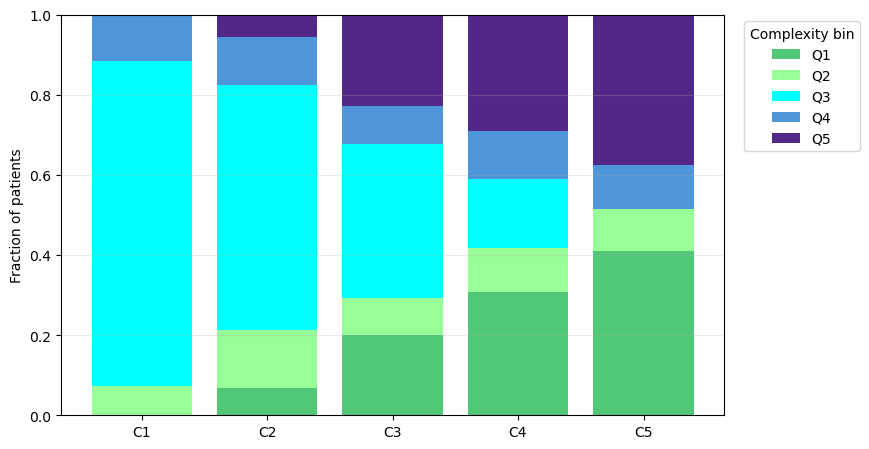

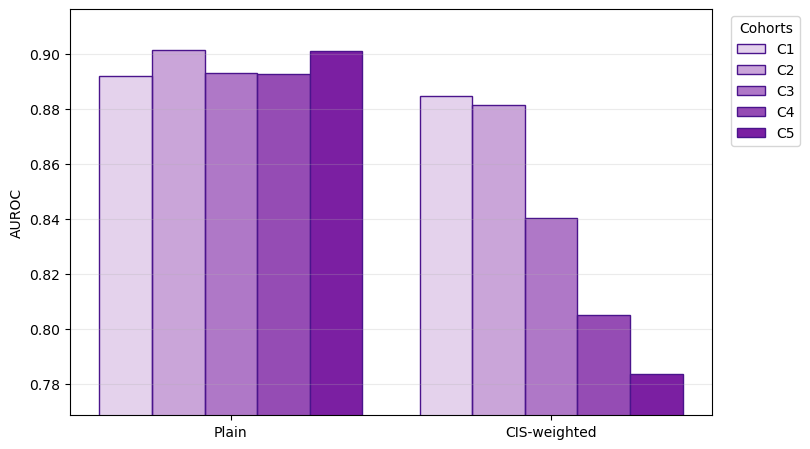

In [23]:
# Figures
#   1) complexity composition
#   2) LSTM: grouped by score type, bars are cohorts
#   3) all models: same grouping style

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cohort_order = list(cohort_target_probs.keys())
model_order = ["LSTM", "LR", "RF", "GBDT"]

# Cohort styling for grouped plots
# Same purple hue with different intensity levels for cohorts
from matplotlib.colors import to_rgba

purple_base = "#7B1FA2"  # base purple
cohort_facecolors = [
    to_rgba(purple_base, 0.20),  # 10%
    to_rgba(purple_base, 0.40),  # 20%
    to_rgba(purple_base, 0.60),  # 30%
    to_rgba(purple_base, 0.80),  # 40%
    to_rgba(purple_base, 1.0),  # 50%
]
cohort_edgecolor = "#4A148C"

# Figure 1: stacked cohort composition
# tiers remain color-coded
comp_rows = []
for cohort_name, info in sampled_cohort_store.items():
    fr = info["observed_bin_frac"]
    for b, frac in zip([1, 2, 3, 4, 5], fr):
        comp_rows.append({
            "cohort": cohort_name,
            "complexity_bin": f"Q{b}",
            "fraction": float(frac)
        })

comp_df = pd.DataFrame(comp_rows)
comp_pivot = comp_df.pivot(index="cohort", columns="complexity_bin", values="fraction")
comp_pivot = comp_pivot.reindex(cohort_order)
comp_pivot = comp_pivot[[f"Q{i}" for i in [1, 2, 3, 4, 5]]]

fig, ax = plt.subplots(figsize=(8.8, 4.6))
x = np.arange(comp_pivot.shape[0])
bottom = np.zeros(comp_pivot.shape[0])
tier_colors = {
    "Q1": "#50C878",
    "Q2": "#98FF98",
    "Q3": "#00FFFF",
    "Q4": "#4E95D9",
    "Q5": "#512888",
}

for q in comp_pivot.columns:
    vals = comp_pivot[q].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=q, color=tier_colors[q])
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(comp_pivot.index)
ax.set_ylabel("Fraction of patients")
ax.legend(title="Complexity bin", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig('Figs/Figure4_cohort.pdf')
plt.show()

# Helper 1: one-model grouped bars
# x-axis groups = plain / CIS-weighted
# bars inside each group = cohorts
def plot_one_model_grouped(eval_df, model_name, fname, metric_base="auroc", zoom_pad=0.01):
    dfm = eval_df[eval_df["model"] == model_name].copy()
    dfm = dfm.set_index("cohort").loc[cohort_order].reset_index()

    if metric_base == "auroc":
        score_groups = [("Plain", "plain_auroc"), ("CIS-weighted", "cis_auroc")]
        ylab = "AUROC"
        title = f"{model_name}: Plain vs CIS-weighted AUROC"
    else:
        score_groups = [("Plain", "plain_auprc"), ("CIS-weighted", "cis_auprc")]
        ylab = "AUPRC"
        title = f"{model_name}: Plain vs CIS-weighted AUPRC"

    vals = []
    for _, col in score_groups:
        vals.extend(dfm[col].to_numpy().tolist())
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]

    ymin = max(0.0, float(vals.min()) - zoom_pad)
    ymax = min(1.0, float(vals.max()) + zoom_pad)

    x = np.arange(len(score_groups))
    n_cohorts = len(cohort_order)
    width = 0.82 / n_cohorts

    fig, ax = plt.subplots(figsize=(8.2, 4.6))

    for j, cohort_name in enumerate(cohort_order):
        heights = [dfm.loc[dfm["cohort"] == cohort_name, col].values[0] for _, col in score_groups]
        ax.bar(
            x + (j - (n_cohorts - 1) / 2) * width,
            heights,
            width=width,
            label=cohort_name,
            color=cohort_facecolors[j % len(cohort_facecolors)],
            edgecolor=cohort_edgecolor,
            linewidth=1.0
        )

    ax.set_xticks(x)
    ax.set_xticklabels([g[0] for g in score_groups])
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel(ylab)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Cohorts", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f'Figs/{fname}')
    plt.show()

# Figure 2-3: LSTM only
plot_one_model_grouped(
    eval_df, model_name="LSTM", fname="Figure4_AUROC.pdf",
    metric_base="auroc", zoom_pad=0.015
)